# TP3 — Data-Centric Design: EDA y Limpieza

**Materia:** 72.75 Aprendizaje Automático (Machine Learning) — ITBA

## 1. Alcance

Este notebook realiza la exploración, limpieza y preparación del dataset
**GPU Resource Reservations**, que contiene información sobre reservas de infraestructura GPU
en un entorno de cómputo distribuido.

El trabajo abarca:

1. **Carga y visión general:** importar el dataset, verificar tipos y valores faltantes.
2. **EDA visual:** distribuciones numéricas, categóricas y distribución por clase.
3. **Análisis de leakage:** identificar features con información post-hoc o derivadas.
4. **Feature engineering:** eliminar columnas problemáticas con justificación.
5. **Encoding:** variables categóricas → numéricas (OHE).
6. **Análisis de correlación y outliers.**
7. **Split temporal y export:** separar train/test por orden cronológico y exportar CSVs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

RANDOM_STATE = 42
TARGET = "canceled_job"

## 2. Carga del dataset

In [2]:
df = pd.read_csv("dataset/gpu_resource_reservations.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (9551, 29)


,datacenter,canceled_job,hours_before_execution,request_month,request_week,request_day,peak_gpu_hours,offpeak_gpu_hours,num_primary_processes,num_auxiliary_processes,...,resource_modifications,reservation_commitment,queue_wait_time,workload_profile,estimated_cost_per_hour,reserved_storage_units,special_resource_requests,total_gpu_hours,total_processes,high_value_client
0,GPU_Cluster_AA,0,44,6,25,22,32604.2,103519.0,2,0.0,...,0,no_commitment,0,single_experiment,106.47,0,0,136123.2,2.0,0
1,GPU_Cluster_BB,1,261,4,17,28,18197.6,20437.1,2,0.0,...,0,no_commitment,0,single_experiment,109.80,0,1,38634.7,2.0,0
2,GPU_Cluster_BB,0,75,1,2,8,27098.0,8232.0,1,0.0,...,0,no_commitment,0,multi_run_experiment,67.00,0,2,35330.0,1.0,0
3,GPU_Cluster_BB,1,56,2,5,1,0.0,52519.6,2,0.0,...,0,locked_allocation,0,single_experiment,60.00,0,0,52519.6,2.0,0
4,GPU_Cluster_BB,1,236,5,20,18,11980.3,38632.2,3,0.0,...,0,no_commitment,0,single_experiment,220.40,0,2,50612.5,3.0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   datacenter                  9551 non-null   object 
 1   canceled_job                9551 non-null   int64  
 2   hours_before_execution      9551 non-null   int64  
 3   request_month               9551 non-null   int64  
 4   request_week                9551 non-null   int64  
 5   request_day                 9551 non-null   int64  
 6   peak_gpu_hours              9551 non-null   float64
 7   offpeak_gpu_hours           9551 non-null   float64
 8   num_primary_processes       9551 non-null   int64  
 9   num_auxiliary_processes     9551 non-null   float64
 10  num_background_processes    9551 non-null   int64  
 11  service_tier                9551 non-null   object 
 12  client_type                 9551 non-null   object 
 13  request_channel             9551 

In [4]:
print("Valores faltantes por columna:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Ninguno — dataset completo")
print(f"\nTotal: {missing.sum()}")

Valores faltantes por columna:
Ninguno — dataset completo

Total: 0


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
datacenter,9551,2,GPU_Cluster_BB,6249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canceled_job,9551.0,NaN,NaN,NaN,0.370432,0.482946,0.0,0.0,0.0,1.0,1.0
hours_before_execution,9551.0,NaN,NaN,NaN,104.687153,107.977728,0.0,18.0,69.0,162.0,629.0
request_month,9551.0,NaN,NaN,NaN,6.544236,3.085094,1.0,4.0,7.0,9.0,12.0
request_week,9551.0,NaN,NaN,NaN,27.117056,13.594698,1.0,16.0,27.0,38.0,53.0
request_day,9551.0,NaN,NaN,NaN,15.743796,8.780953,1.0,8.0,16.0,23.0,31.0
peak_gpu_hours,9551.0,NaN,NaN,NaN,13167.793707,15068.280782,0.0,0.0,11054.6,22620.5,156084.3
offpeak_gpu_hours,9551.0,NaN,NaN,NaN,35547.074715,28864.914248,0.0,15790.4,28846.1,47398.4,414493.4
num_primary_processes,9551.0,NaN,NaN,NaN,1.850173,0.485669,0.0,2.0,2.0,2.0,4.0
num_auxiliary_processes,9551.0,NaN,NaN,NaN,0.105225,0.408195,0.0,0.0,0.0,0.0,3.0


## 3. Distribución de la variable objetivo

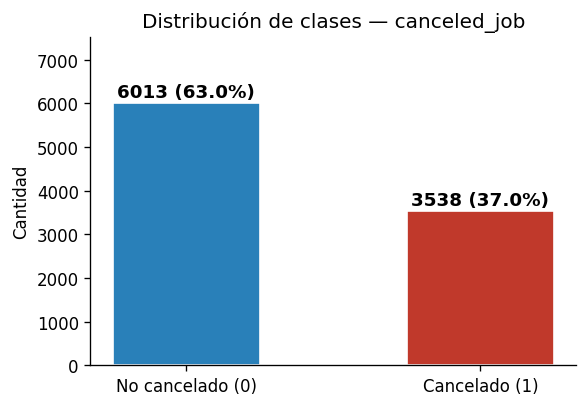


Desbalance: 1.70:1 (no cancelado / cancelado)


In [6]:
counts = df[TARGET].value_counts().sort_index()
labels = ["No cancelado (0)", "Cancelado (1)"]
colors = ["#2980B9", "#C0392B"]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"{val} ({100*val/len(df):.1f}%)", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de clases — canceled_job")
ax.set_ylim(0, counts.max() * 1.25)
plt.tight_layout()
plt.show()

print(f"\nDesbalance: {counts[0]/counts[1]:.2f}:1 (no cancelado / cancelado)")

## 4. EDA visual

### 4.1 Variables numéricas — distribuciones

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]
print(f"Variables numéricas ({len(num_cols)}): {num_cols}")

Variables numéricas (20): ['hours_before_execution', 'request_month', 'request_week', 'request_day', 'peak_gpu_hours', 'offpeak_gpu_hours', 'num_primary_processes', 'num_auxiliary_processes', 'num_background_processes', 'returning_client', 'previous_job_cancellations', 'successful_previous_jobs', 'resource_modifications', 'queue_wait_time', 'estimated_cost_per_hour', 'reserved_storage_units', 'special_resource_requests', 'total_gpu_hours', 'total_processes', 'high_value_client']


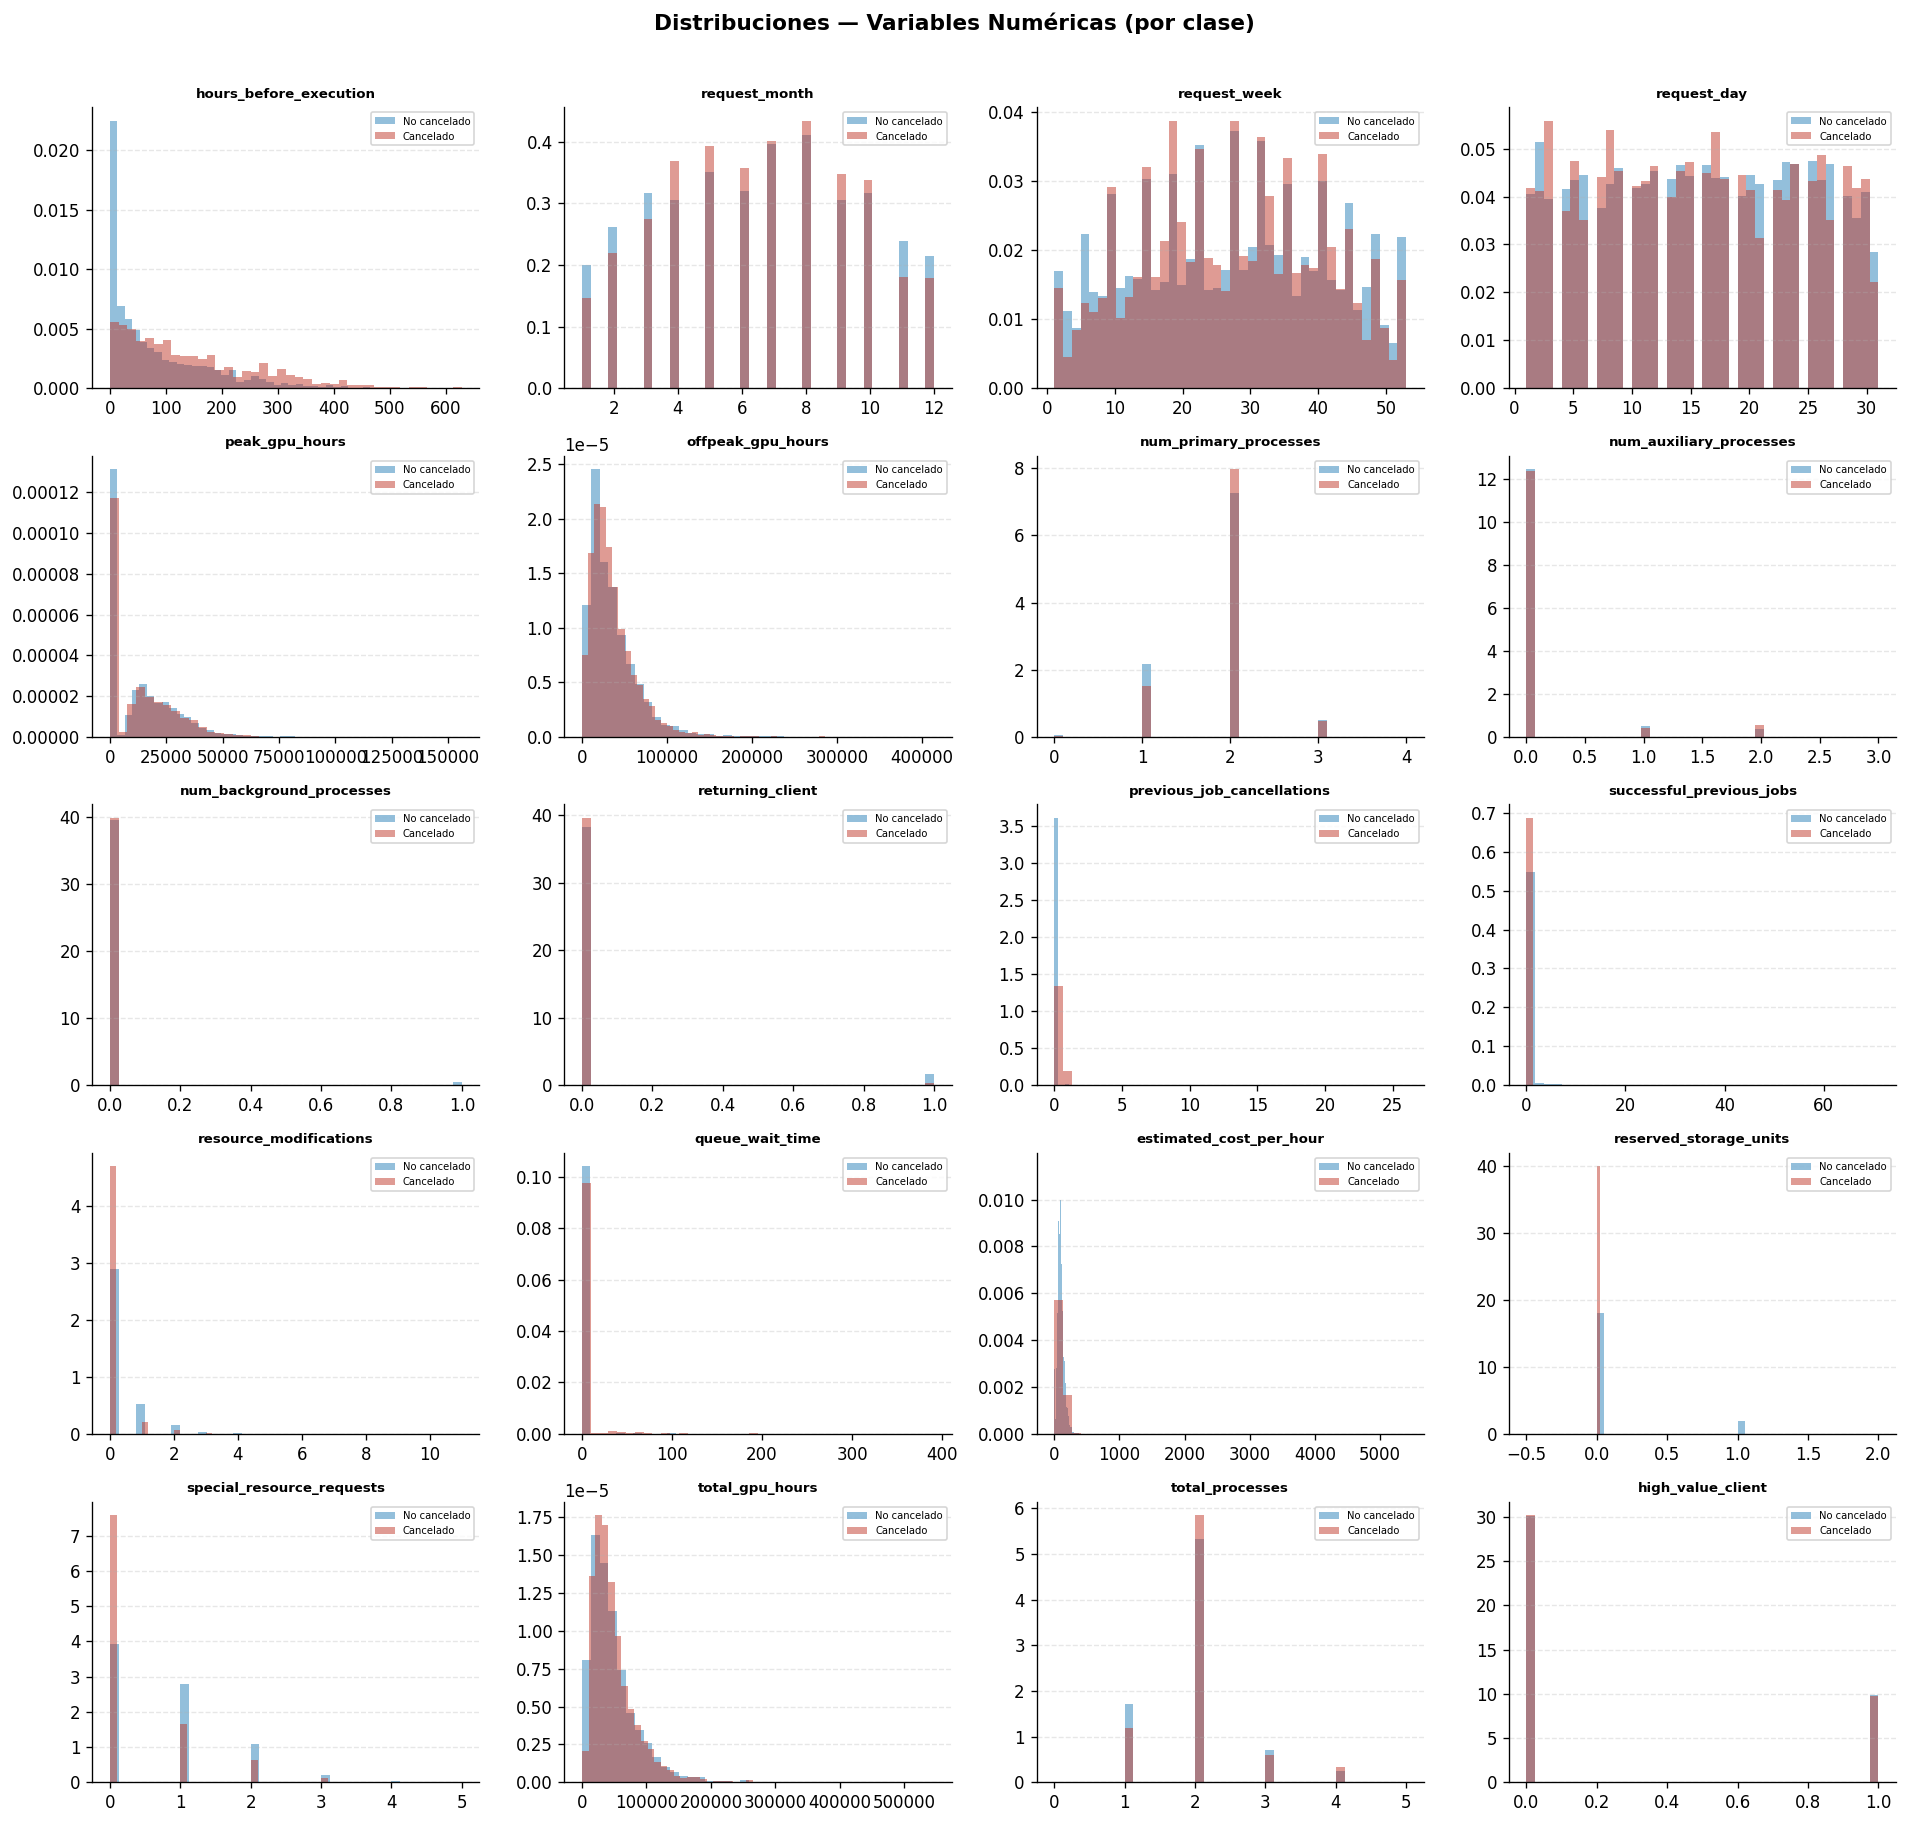

In [8]:
n_cols_plot = 4
n_rows_plot = -(-len(num_cols) // n_cols_plot)
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 3))
fig.suptitle("Distribuciones — Variables Numéricas (por clase)", fontsize=13, fontweight="bold", y=1.01)

for idx, col in enumerate(num_cols):
    ax = axes.flat[idx]
    for val, color, label in [(0, "#2980B9", "No cancelado"), (1, "#C0392B", "Cancelado")]:
        data = df.loc[df[TARGET] == val, col].dropna()
        ax.hist(data, bins=40, density=True, alpha=0.5, color=color, label=label, edgecolor="none")
    ax.set_title(col, fontsize=8, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=6)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

for idx in range(len(num_cols), len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

### 4.2 Variables categóricas — distribución por clase

Variables categóricas (8): ['datacenter', 'service_tier', 'client_type', 'request_channel', 'reserved_gpu_type', 'assigned_gpu_type', 'reservation_commitment', 'workload_profile']


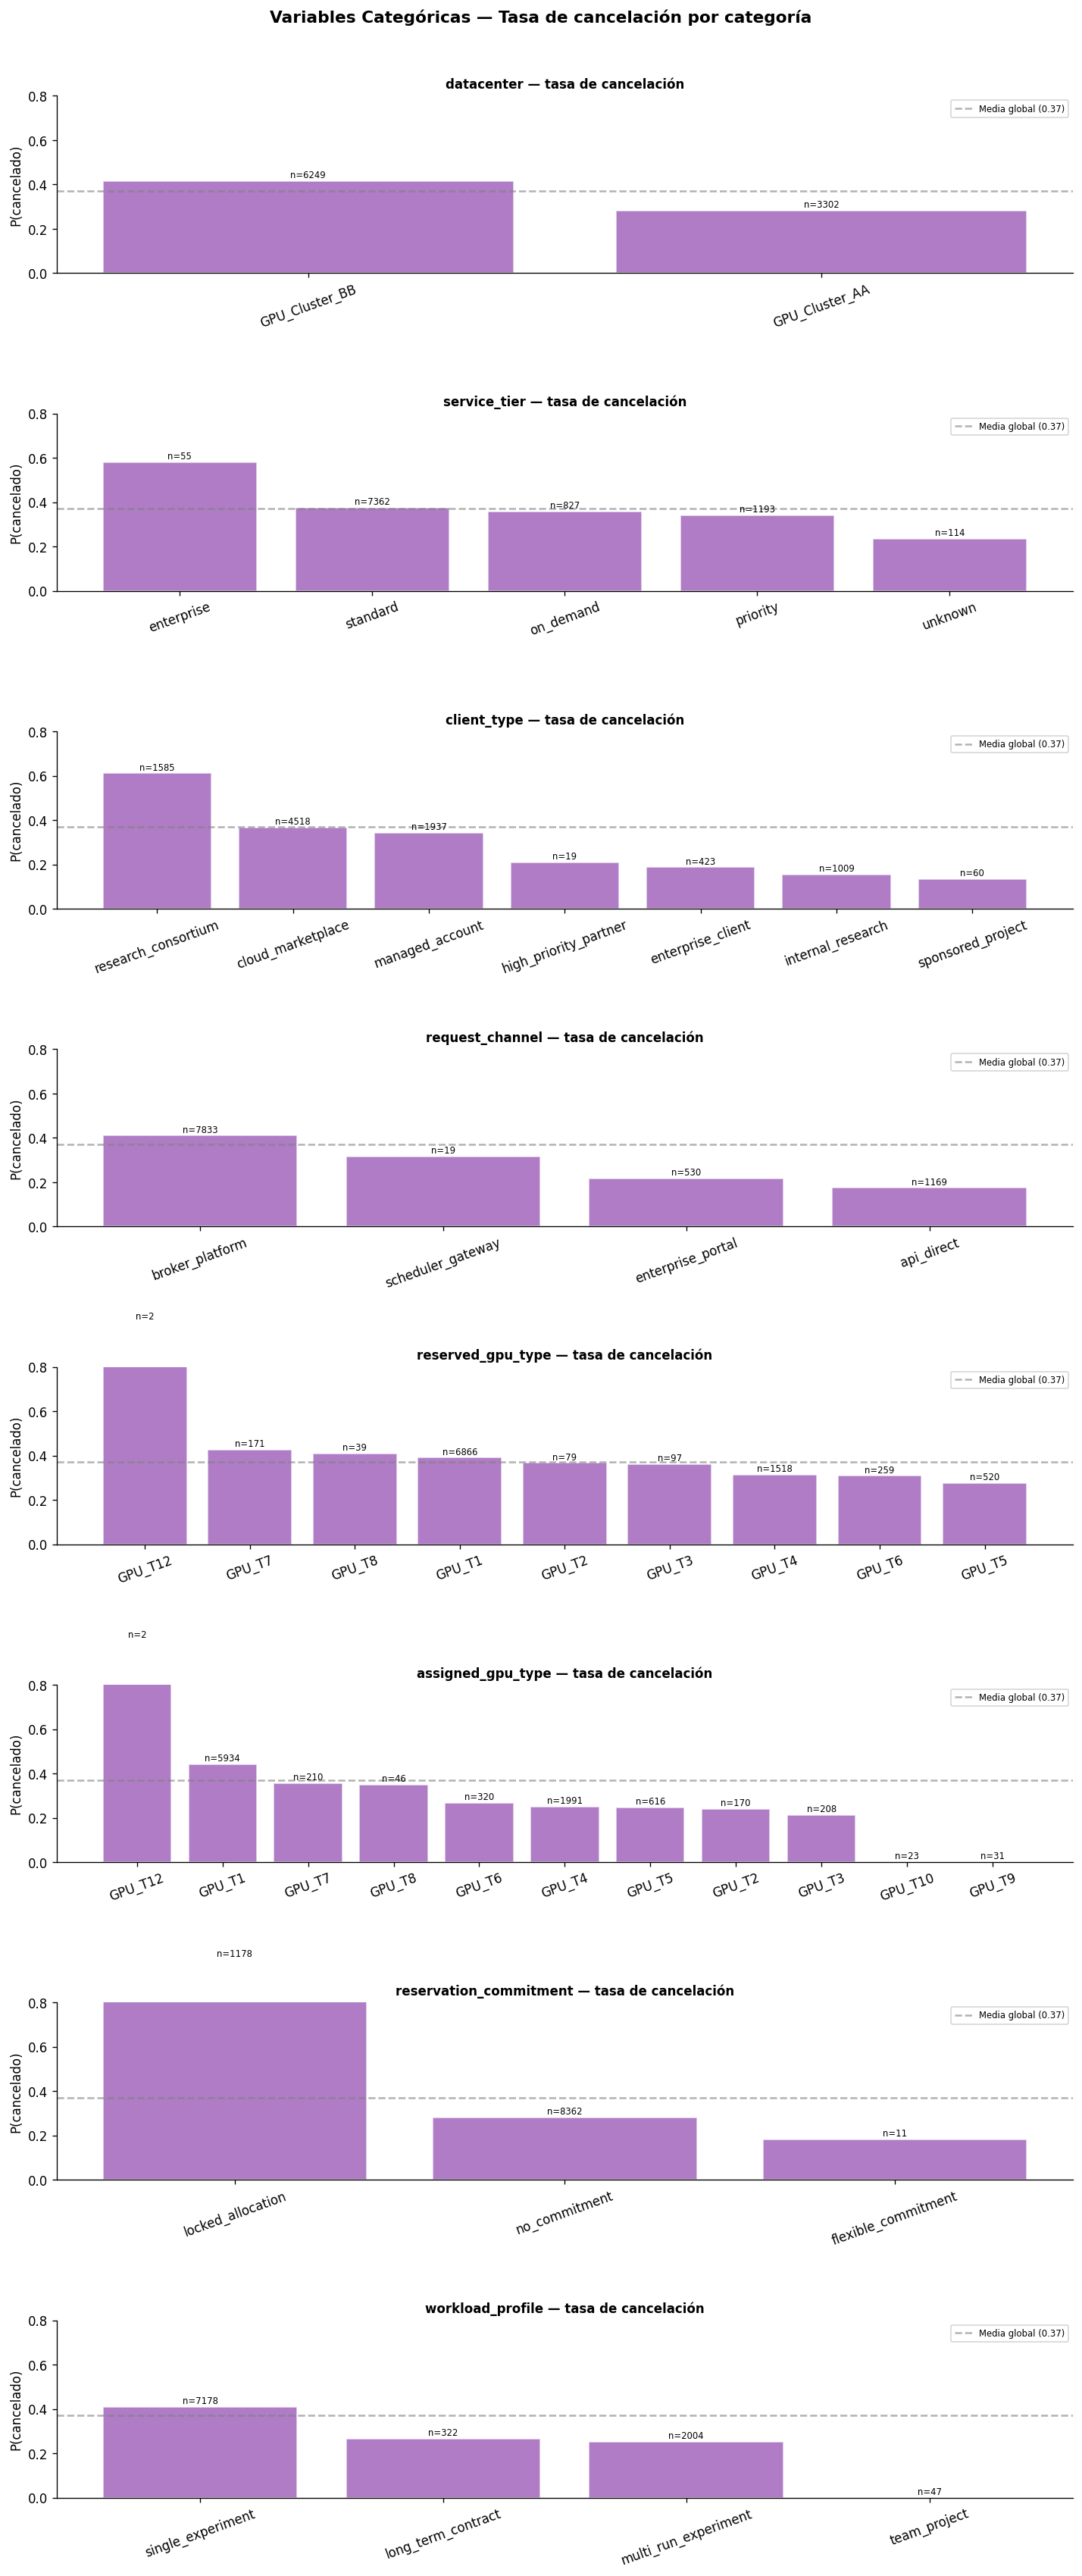

In [9]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Variables categóricas ({len(cat_cols)}): {cat_cols}")

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, len(cat_cols) * 3.5))
fig.suptitle("Variables Categóricas — Tasa de cancelación por categoría", fontsize=13, fontweight="bold", y=1.01)

for ax, col in zip(axes, cat_cols):
    cancel_rate = df.groupby(col)[TARGET].agg(["mean", "count"]).reset_index()
    cancel_rate = cancel_rate.sort_values("mean", ascending=False)
    bars = ax.bar(cancel_rate[col], cancel_rate["mean"], color="#8E44AD", alpha=0.7, edgecolor="white")
    for bar, cnt in zip(bars, cancel_rate["count"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"n={cnt}", ha="center", va="bottom", fontsize=7)
    ax.set_title(f"{col} — tasa de cancelación", fontsize=10, fontweight="bold")
    ax.set_ylabel("P(cancelado)")
    ax.set_ylim(0, 0.8)
    ax.axhline(df[TARGET].mean(), color="gray", linestyle="--", alpha=0.6, label=f"Media global ({df[TARGET].mean():.2f})")
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 4.3 Análisis temporal — evolución de la tasa de cancelación

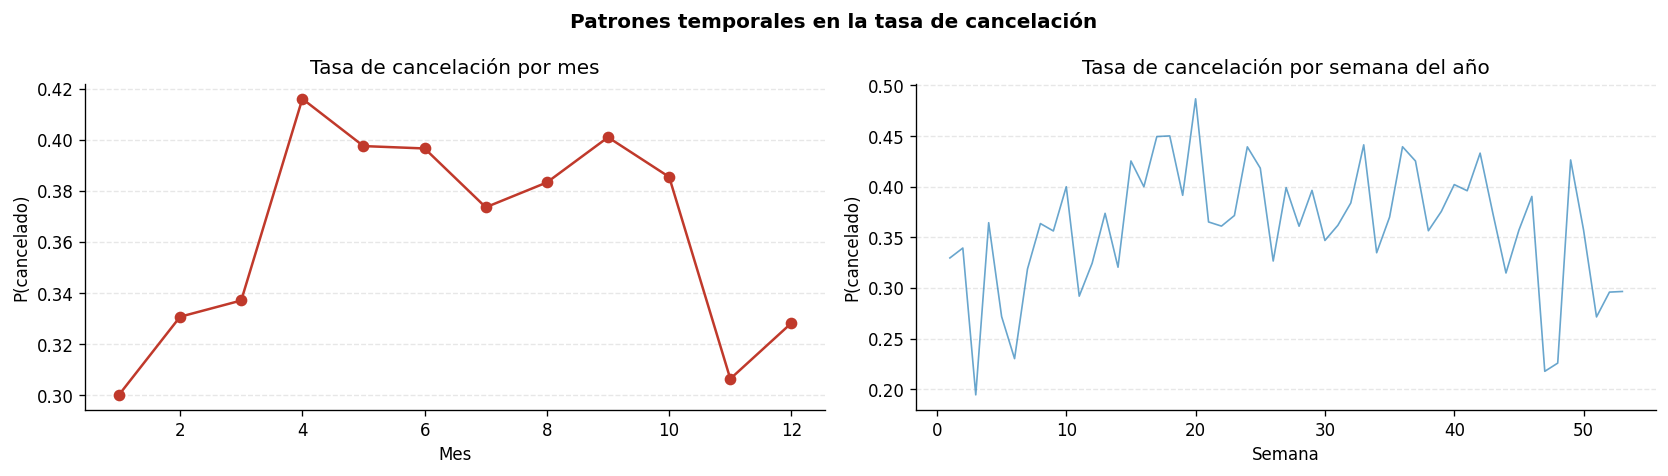

Observación: si la tasa de cancelación varía según el tiempo, el split temporal
es crítico para evitar que el modelo 'vea' patrones futuros durante el entrenamiento.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly = df.groupby("request_month")[TARGET].agg(["mean", "count"])
axes[0].plot(monthly.index, monthly["mean"], marker="o", color="#C0392B")
axes[0].set_title("Tasa de cancelación por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("P(cancelado)")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

weekly = df.groupby("request_week")[TARGET].agg(["mean", "count"])
axes[1].plot(weekly.index, weekly["mean"], color="#2980B9", alpha=0.7, linewidth=1)
axes[1].set_title("Tasa de cancelación por semana del año")
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("P(cancelado)")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle("Patrones temporales en la tasa de cancelación", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Observación: si la tasa de cancelación varía según el tiempo, el split temporal")
print("es crítico para evitar que el modelo 'vea' patrones futuros durante el entrenamiento.")

## 5. Análisis de leakage potencial

Antes de modelar, es fundamental identificar features que podrían introducir **data leakage**,
es decir, información que no estaría disponible en el momento de la predicción real.

### 5.1 Columnas derivadas (leakage por construcción)

- `total_gpu_hours` = `peak_gpu_hours` + `offpeak_gpu_hours` (suma exacta)
- `total_processes` = `num_primary_processes` + `num_auxiliary_processes` + `num_background_processes` (suma exacta)

Estas columnas son combinaciones lineales exactas de otras features. Incluirlas no agrega
información al modelo pero sí introduce redundancia perfecta → **se eliminan**.

In [11]:
check1 = (df["total_gpu_hours"] - df["peak_gpu_hours"] - df["offpeak_gpu_hours"]).abs().max()
check2 = (df["total_processes"] - df["num_primary_processes"] - df["num_auxiliary_processes"] - df["num_background_processes"]).abs().max()

print(f"max |total_gpu_hours - (peak + offpeak)|  = {check1:.2e}  → derivada exacta, DROP")
print(f"max |total_processes - (primary+aux+bg)| = {check2:.2e}  → derivada exacta, DROP")

max |total_gpu_hours - (peak + offpeak)|  = 5.82e-11  → derivada exacta, DROP
max |total_processes - (primary+aux+bg)| = 0.00e+00  → derivada exacta, DROP


### 5.2 `assigned_gpu_type` — análisis de leakage

`assigned_gpu_type` indica el tipo de GPU **finalmente asignado** para la ejecución.
Si la asignación ocurre **antes** de la cancelación (como parte del proceso de reserva),
no hay leakage — la información es disponible al momento de predecir.

Sin embargo, si la asignación solo ocurre para jobs **no cancelados** (post-execution), 
incluirla sería leakage severo. Analizamos la distribución:

In [12]:
assigned_vs_cancel = df.groupby(["assigned_gpu_type", TARGET]).size().unstack(fill_value=0)
assigned_vs_cancel["cancel_rate"] = assigned_vs_cancel[1] / assigned_vs_cancel.sum(axis=1)
print("Distribución de assigned_gpu_type por clase:")
print(assigned_vs_cancel.round(3))

print("\nConlusión: assigned_gpu_type aparece en AMBAS clases (cancelados y no cancelados)")
print("→ Es parte del proceso de reserva, no post-ejecución")

# Pero: differ con reserved_gpu_type?
mismatch = (df["reserved_gpu_type"] != df["assigned_gpu_type"]).sum()
print(f"\nFilas donde reserved != assigned: {mismatch} ({100*mismatch/len(df):.1f}%)")
print("→ La asignación puede diferir de la solicitud (reemplazo de hardware)")
print("→ Se INCLUYE: refleja la GPU real del trabajo, disponible al momento de la reserva")

Distribución de assigned_gpu_type por clase:
canceled_job          0     1  cancel_rate
assigned_gpu_type                         
GPU_T1             3308  2626        0.443
GPU_T10              23     0        0.000
GPU_T12               0     2        1.000
GPU_T2              129    41        0.241
GPU_T3              164    44        0.212
GPU_T4             1493   498        0.250
GPU_T5              465   151        0.245
GPU_T6              235    85        0.266
GPU_T7              135    75        0.357
GPU_T8               30    16        0.348
GPU_T9               31     0        0.000

Conlusión: assigned_gpu_type aparece en AMBAS clases (cancelados y no cancelados)
→ Es parte del proceso de reserva, no post-ejecución

Filas donde reserved != assigned: 1161 (12.2%)
→ La asignación puede diferir de la solicitud (reemplazo de hardware)
→ Se INCLUYE: refleja la GPU real del trabajo, disponible al momento de la reserva


## 6. Feature engineering

**Decisiones:**
1. **Drop** `total_gpu_hours` y `total_processes` — derivadas exactas (redundancia perfecta)
2. **Mantener** `assigned_gpu_type` — disponible en el momento de la reserva, no post-ejecución
3. **Mantener** `request_month`, `request_week`, `request_day` — features temporales legítimas
   (el modelo puede aprender patrones estacionales, pero el split debe ser temporal)
4. **Mantener** `service_tier = "unknown"` como categoría propia — no imputar

In [13]:
COLS_TO_DROP = ["total_gpu_hours", "total_processes"]

df_clean = df.drop(columns=COLS_TO_DROP).copy()
print(f"Columnas originales:  {df.shape[1]}")
print(f"Columnas eliminadas:  {len(COLS_TO_DROP)} ({COLS_TO_DROP})")
print(f"Columnas restantes:   {df_clean.shape[1]}")

Columnas originales:  29
Columnas eliminadas:  2 (['total_gpu_hours', 'total_processes'])
Columnas restantes:   27


## 7. Encoding de variables categóricas

Todas las variables categóricas son nominales (sin orden intrínseco claro) → **One-Hot Encoding**.

- `drop_first=True` para evitar multicolinealidad perfecta (dummy variable trap)
- Las columnas meta-temporales (`request_month`, `request_week`, `request_day`) se tratan
  como numéricas (ya son enteros con semántica ordinal de tiempo)

**Nota:** `service_tier` incluye la categoría `"unknown"` que se codifica como columna propia.
Esta categoría puede ser informativa (clientes sin tier definido) y no debe imputarse.

In [14]:
CAT_COLS = df_clean.select_dtypes(include="object").columns.tolist()
print(f"Columnas categóricas a encodear: {CAT_COLS}")

# Guardar columnas de cohortes ANTES del encoding para uso en notebook 03
COHORT_COLS = ["client_type", "service_tier", "reserved_gpu_type"]
df_clean[["client_type", "service_tier", "reserved_gpu_type"]].to_csv(
    "dataset/cohort_labels.csv", index=True
)
print("\nColumnas de cohorte guardadas en dataset/cohort_labels.csv para análisis posterior")

Columnas categóricas a encodear: ['datacenter', 'service_tier', 'client_type', 'request_channel', 'reserved_gpu_type', 'assigned_gpu_type', 'reservation_commitment', 'workload_profile']

Columnas de cohorte guardadas en dataset/cohort_labels.csv para análisis posterior


In [15]:
df_encoded = pd.get_dummies(df_clean, columns=CAT_COLS, drop_first=True, dtype=int)

print(f"Columnas antes del encoding: {df_clean.shape[1]}")
print(f"Columnas después del encoding: {df_encoded.shape[1]}")
print(f"\nNuevas columnas OHE:")
new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
for c in new_cols:
    print(f"  {c}")

Columnas antes del encoding: 27
Columnas después del encoding: 56

Nuevas columnas OHE:
  datacenter_GPU_Cluster_BB
  service_tier_on_demand
  service_tier_priority
  service_tier_standard
  service_tier_unknown
  client_type_enterprise_client
  client_type_high_priority_partner
  client_type_internal_research
  client_type_managed_account
  client_type_research_consortium
  client_type_sponsored_project
  request_channel_broker_platform
  request_channel_enterprise_portal
  request_channel_scheduler_gateway
  reserved_gpu_type_GPU_T12
  reserved_gpu_type_GPU_T2
  reserved_gpu_type_GPU_T3
  reserved_gpu_type_GPU_T4
  reserved_gpu_type_GPU_T5
  reserved_gpu_type_GPU_T6
  reserved_gpu_type_GPU_T7
  reserved_gpu_type_GPU_T8
  assigned_gpu_type_GPU_T10
  assigned_gpu_type_GPU_T12
  assigned_gpu_type_GPU_T2
  assigned_gpu_type_GPU_T3
  assigned_gpu_type_GPU_T4
  assigned_gpu_type_GPU_T5
  assigned_gpu_type_GPU_T6
  assigned_gpu_type_GPU_T7
  assigned_gpu_type_GPU_T8
  assigned_gpu_type_GPU_

## 8. Análisis de correlación (post-encoding)

Análisis de correlación de las variables numéricas originales con el target,
e identificación de pares altamente correlacionados.

In [16]:
# Correlación con el target (ordenada por |r|)
corr_with_target = df_encoded.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Top 20 features más correlacionadas con canceled_job:")
print(corr_with_target.head(20).round(4).to_string())

Top 20 features más correlacionadas con canceled_job:
reservation_commitment_locked_allocation    0.4831
reservation_commitment_no_commitment       -0.4798
hours_before_execution                      0.2761
special_resource_requests                  -0.2315
client_type_research_consortium             0.2220
reserved_storage_units                     -0.1931
request_channel_broker_platform             0.1758
resource_modifications                     -0.1587
client_type_internal_research              -0.1543
workload_profile_single_experiment          0.1445
datacenter_GPU_Cluster_BB                   0.1309
assigned_gpu_type_GPU_T4                   -0.1278
workload_profile_multi_run_experiment      -0.1264
previous_job_cancellations                  0.1118
returning_client                           -0.0906
client_type_enterprise_client              -0.0819
request_channel_enterprise_portal          -0.0770
assigned_gpu_type_GPU_T5                   -0.0681
num_primary_processes       

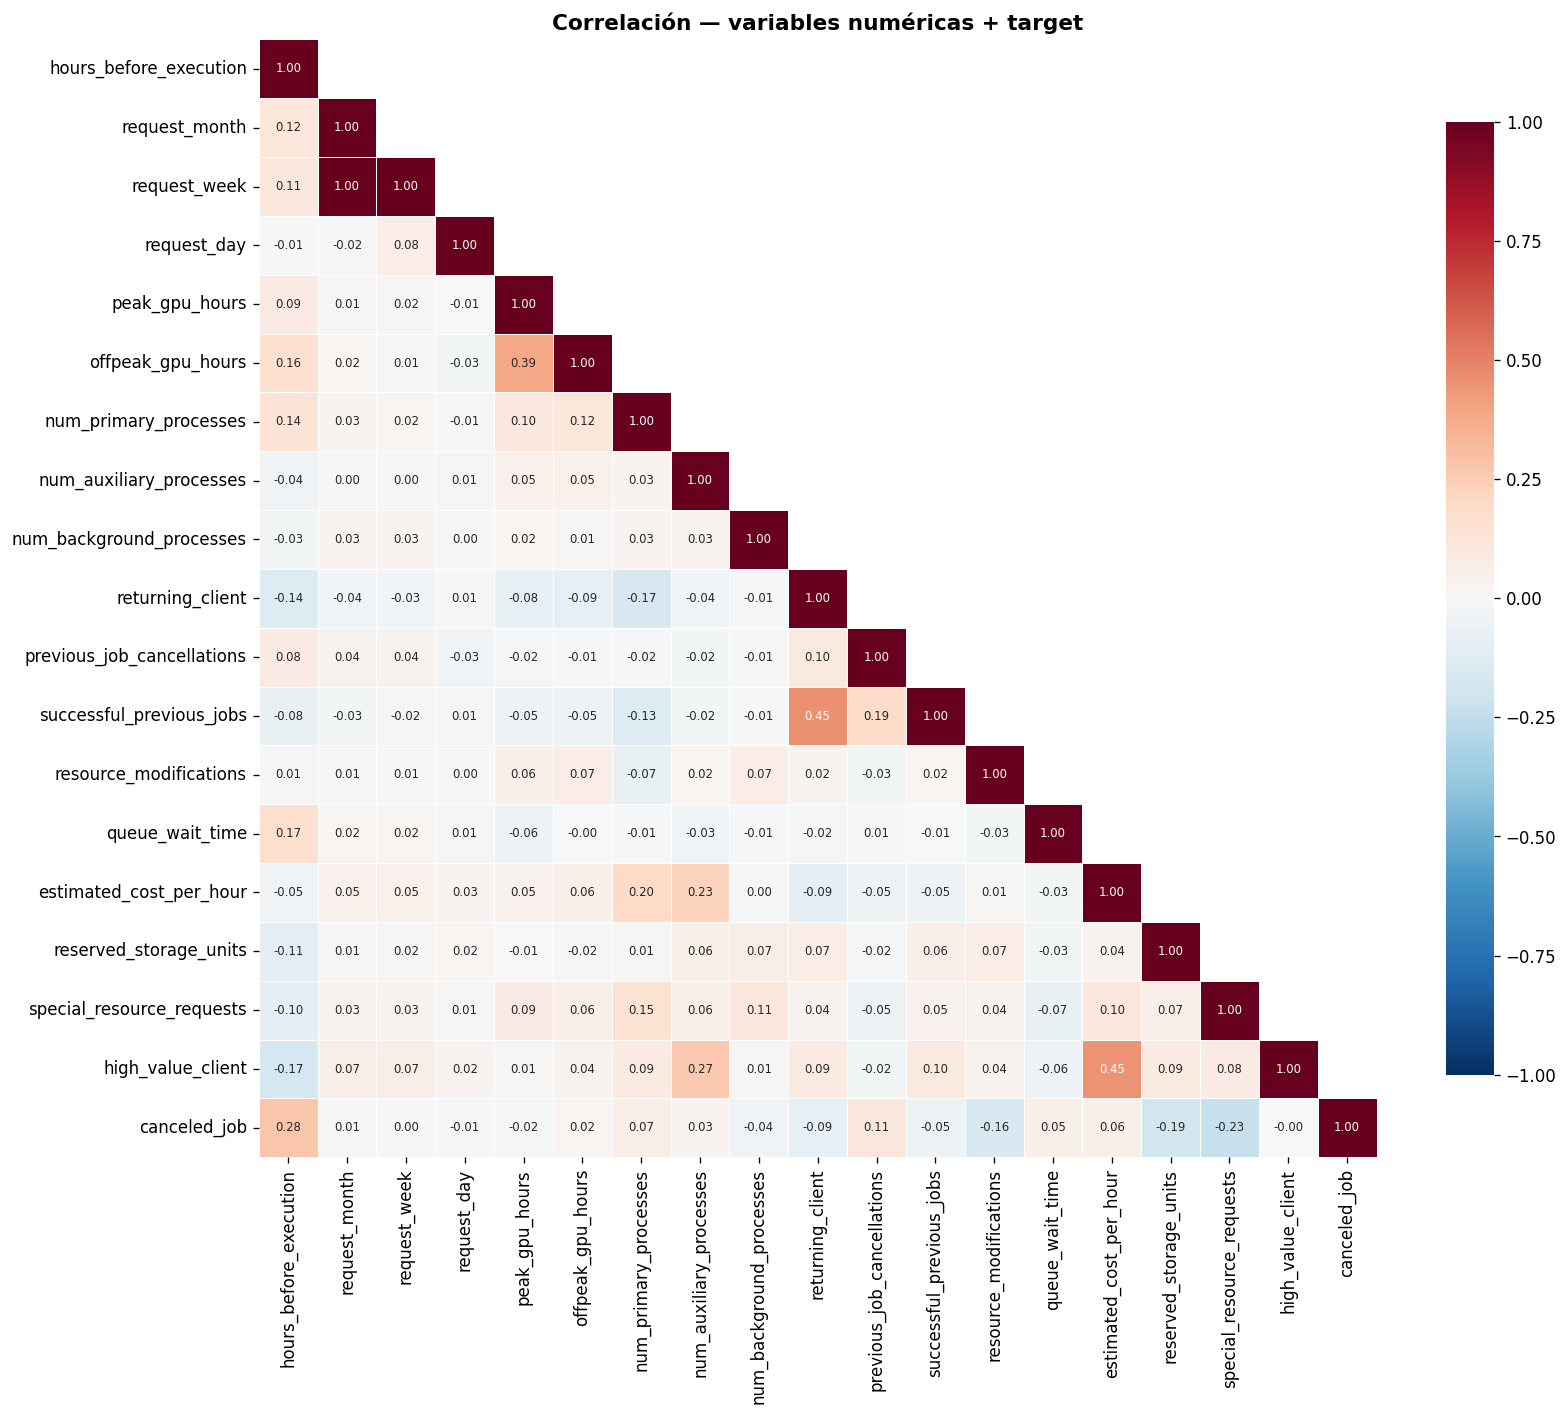

In [17]:
# Heatmap de correlaciones (solo variables numéricas originales para legibilidad)
orig_num_cols = [c for c in df_clean.select_dtypes(include=["int64","float64"]).columns if c != TARGET]
corr_matrix = df_encoded[orig_num_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlación — variables numéricas + target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Análisis de outliers

In [18]:
outlier_summary = []
for col in orig_num_cols:
    vals = df_encoded[col]
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((vals < lower) | (vals > upper)).sum()
    pct = 100 * n_out / len(vals)
    outlier_summary.append({"feature": col, "n_outliers": n_out, "pct": round(pct, 1)})

out_df = pd.DataFrame(outlier_summary).sort_values("pct", ascending=False)
print("Outliers IQR (1.5) por feature:")
print(out_df.to_string(index=False))
print("\nDecisión: NO se eliminan outliers.")
print("Los valores extremos en GPU hours/cost pueden representar workloads legítimamente")
print("grandes o costosos. Son señal informativa, no ruido de medición.")

Outliers IQR (1.5) por feature:
                   feature  n_outliers  pct
     num_primary_processes        2356 24.7
         high_value_client        2352 24.6
    resource_modifications        1444 15.1
   num_auxiliary_processes         666  7.0
    reserved_storage_units         571  6.0
previous_job_cancellations         509  5.3
         offpeak_gpu_hours         381  4.0
  successful_previous_jobs         310  3.2
          returning_client         295  3.1
   estimated_cost_per_hour         299  3.1
           queue_wait_time         262  2.7
    hours_before_execution         249  2.6
 special_resource_requests         217  2.3
            peak_gpu_hours         112  1.2
  num_background_processes          75  0.8
             request_month           0  0.0
               request_day           0  0.0
              request_week           0  0.0

Decisión: NO se eliminan outliers.
Los valores extremos en GPU hours/cost pueden representar workloads legítimamente
grandes o cost

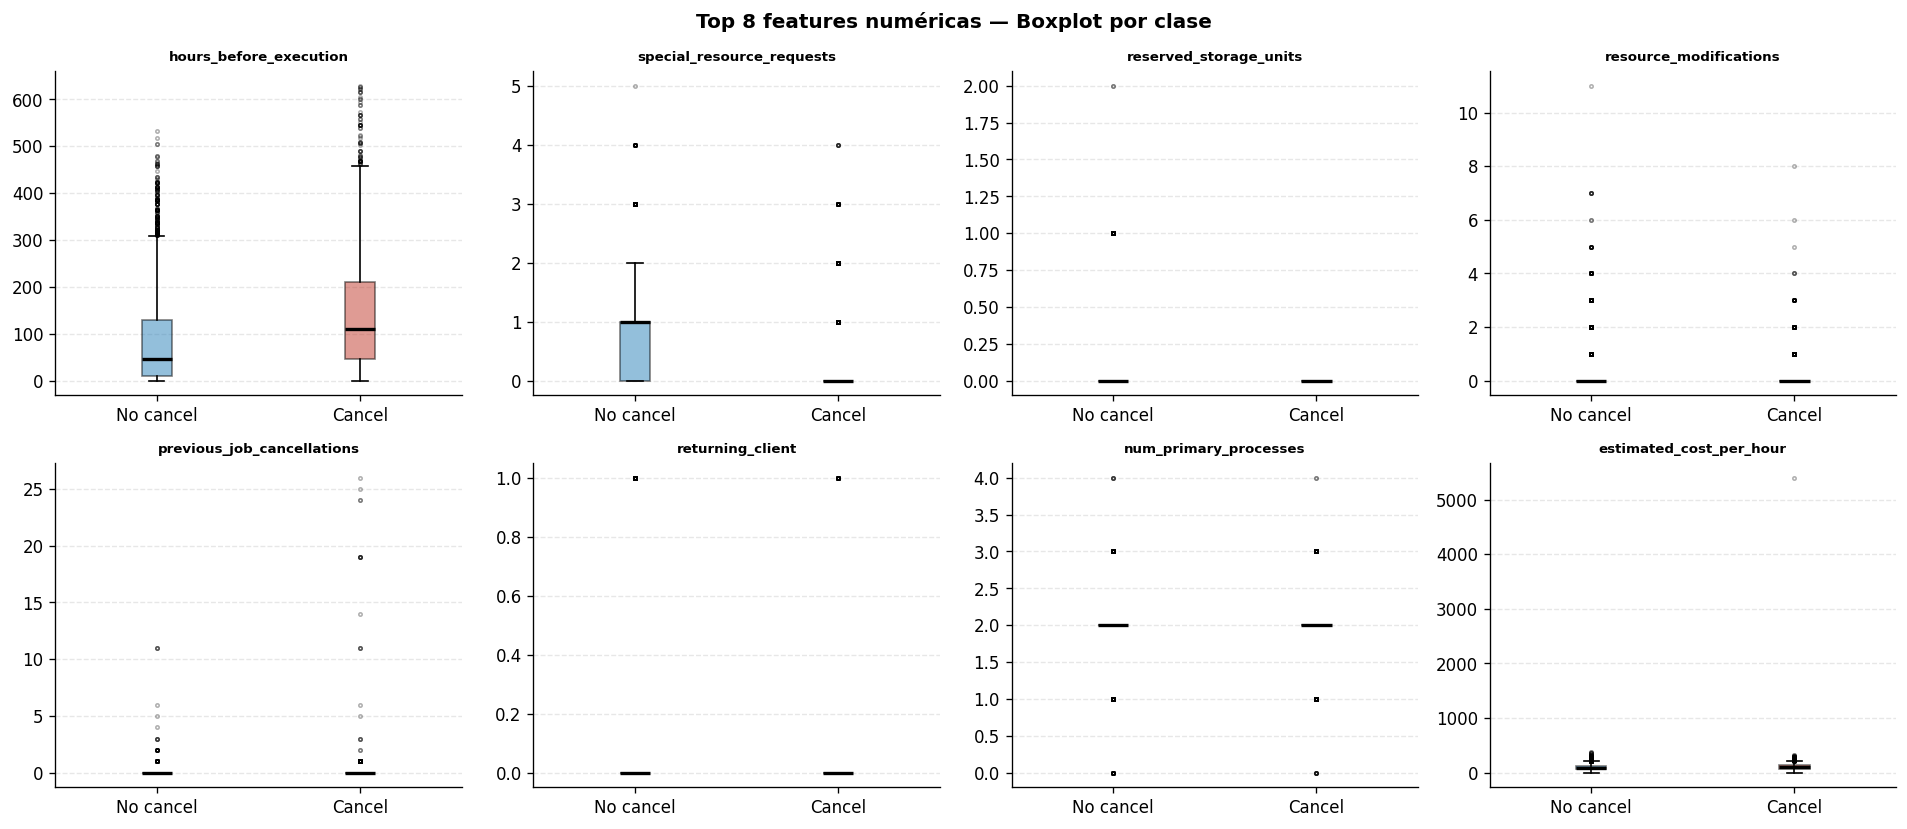

In [19]:
# Boxplots de features continuas más discriminativas por clase
top_num = corr_with_target[corr_with_target.index.isin(orig_num_cols)].head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Top 8 features numéricas — Boxplot por clase", fontsize=12, fontweight="bold")

for ax, col in zip(axes.flat, top_num):
    data = [df_encoded.loc[df_encoded[TARGET] == 0, col],
            df_encoded.loc[df_encoded[TARGET] == 1, col]]
    bp = ax.boxplot(data, vert=True, patch_artist=True, labels=["No cancel", "Cancel"],
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.3))
    bp["boxes"][0].set_facecolor("#2980B9")
    bp["boxes"][0].set_alpha(0.5)
    bp["boxes"][1].set_facecolor("#C0392B")
    bp["boxes"][1].set_alpha(0.5)
    ax.set_title(col, fontsize=8, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Split temporal y export

### Estrategia: split por orden cronológico

El dataset tiene estructura temporal (`request_month`, `request_week`, `request_day`).
Usar un split aleatorio podría introducir **leakage temporal**: el modelo entrenaría
con datos futuros para predecir reservas pasadas, lo que infla artificialmente el rendimiento.

**Estrategia adoptada:**
1. Ordenar el dataset por `(request_month, request_week, request_day)`
2. Primeras 80% filas cronológicas → **Train**
3. Últimas 20% filas cronológicas → **Test** (datos más recientes)

Esto simula un escenario realista: entrenamos con el historial y evaluamos en el futuro.

**CV:** En el notebook 02 se usará `TimeSeriesSplit` en lugar de `StratifiedKFold`
para mantener la integridad temporal también dentro de la validación cruzada.

**Desventaja aceptada:** perdemos la garantía de distribución de clases exacta en cada split,
aunque verificamos que el desbalance sea similar.

In [20]:
# Ordenar cronológicamente
df_sorted = df_encoded.sort_values(
    by=["request_month", "request_week", "request_day"]
).reset_index(drop=True)

# También reordenar cohort_labels en el mismo orden
df_clean_sorted = df_clean.sort_values(
    by=["request_month", "request_week", "request_day"]
).reset_index(drop=True)

# Guardar cohort_labels con el orden cronológico correcto
df_clean_sorted[COHORT_COLS].to_csv("dataset/cohort_labels.csv", index=True)

split_idx = int(len(df_sorted) * 0.80)
print(f"Total filas: {len(df_sorted)}")
print(f"Train (primeras 80%): {split_idx} filas")
print(f"Test  (últimas 20%):  {len(df_sorted) - split_idx} filas")

Total filas: 9551
Train (primeras 80%): 7640 filas
Test  (últimas 20%):  1911 filas


In [21]:
train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

y_train = train_df[TARGET]
y_test  = test_df[TARGET]

print("Distribución de clases post-split:")
split_dist = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Train %": (100 * y_train.value_counts().sort_index() / len(y_train)).round(1),
    "Test":  y_test.value_counts().sort_index(),
    "Test %":  (100 * y_test.value_counts().sort_index() / len(y_test)).round(1),
})
split_dist.index = ["No cancelado (0)", "Cancelado (1)"]
print(split_dist)

print("\nRango temporal en Train:")
print(f"  Mes {train_df['request_month'].min()}–{train_df['request_month'].max()}, "
      f"semana {train_df['request_week'].min()}–{train_df['request_week'].max()}")
print("Rango temporal en Test:")
print(f"  Mes {test_df['request_month'].min()}–{test_df['request_month'].max()}, "
      f"semana {test_df['request_week'].min()}–{test_df['request_week'].max()}")

Distribución de clases post-split:
                  Train  Train %  Test  Test %
No cancelado (0)   4768     62.4  1245    65.1
Cancelado (1)      2872     37.6   666    34.9

Rango temporal en Train:
  Mes 1–10, semana 1–40
Rango temporal en Test:
  Mes 10–12, semana 40–53


In [22]:
os.makedirs("data/processed", exist_ok=True)

train_df.to_csv("data/processed/train.csv", index=False)
test_df.to_csv("data/processed/test.csv", index=False)

# Exportar lista de features (útil en notebooks 02 y 03)
feature_cols = [c for c in df_sorted.columns if c != TARGET]
with open("data/processed/feature_cols.txt", "w") as f:
    f.write("\n".join(feature_cols))

print("Archivos exportados:")
print(f"  data/processed/train.csv  ({len(train_df)} filas, {len(train_df.columns)} columnas)")
print(f"  data/processed/test.csv   ({len(test_df)} filas, {len(test_df.columns)} columnas)")
print(f"  data/processed/feature_cols.txt ({len(feature_cols)} features)")
print(f"  dataset/cohort_labels.csv")

Archivos exportados:
  data/processed/train.csv  (7640 filas, 56 columnas)
  data/processed/test.csv   (1911 filas, 56 columnas)
  data/processed/feature_cols.txt (55 features)
  dataset/cohort_labels.csv


In [23]:
print("=" * 60)
print("RESUMEN DE LA LIMPIEZA")
print("=" * 60)
print(f"Filas originales:              {len(df)}")
print(f"Filas finales (sin cambios):   {len(df_encoded)}")
print(f"Columnas originales:           {df.shape[1]}")
print(f"Columnas tras feature eng:     {df_clean.shape[1]}")
print(f"Columnas tras OHE:             {df_encoded.shape[1]}")
print(f"Missing values:                0")
print(f"Outliers eliminados:           0")
print(f"Columnas eliminadas:           {COLS_TO_DROP} (derivadas exactas)")
print(f"Split: Train={len(train_df)} / Test={len(test_df)} (80/20 cronológico)")

RESUMEN DE LA LIMPIEZA
Filas originales:              9551
Filas finales (sin cambios):   9551
Columnas originales:           29
Columnas tras feature eng:     27
Columnas tras OHE:             56
Missing values:                0
Outliers eliminados:           0
Columnas eliminadas:           ['total_gpu_hours', 'total_processes'] (derivadas exactas)
Split: Train=7640 / Test=1911 (80/20 cronológico)
